In [2]:
import numpy as np
import matplotlib.pyplot as plt

<h1 style="font-size:36px; color:#2c3e50; text-align:center;"> Exploración de Métodos de Optimización</h1>

<p style="font-size:18px">
En esta Tarea1 se abordará la optimización de dos funciones utilizando tres enfoques distintos vistos en clase. 
</p>

<p style="font-size:13px">
Alumnos: 
    Raimundo Barbosa
</p>


###  Métodos de Optimización Aplicados

Los algoritmos fueron:

1. **Gradiente Descendente con Dirección Normalizada**  
2. **Gradiente Descendente con Paso Fijo**  
3. **Método de Newton-Raphson**


### Funciones a Optimizar

Las funciones seleccionadas son:

1. Función no lineal:

$$f_1(x) = -(1.4 - 3x)\sin(18x)$$

2. Función polinómica:

$$f_2(x) = \frac{x^2}{3} - x + \frac{1}{2}$$


<p style="font-size:25px"> Funciones y Derivadas

In [3]:
#para función 1
def f1(x):
    return -(1.4 - 3 * x) * np.sin(18*x)
def df1(x):
    return 3 *np.sin(18*x)- 25.2 * np.cos(18*x) + 54*x* np.cos(18*x)
def ddf1(x):
    return -972*x *np.sin(18*x) + 108* np.cos(18*x) + 453.6 * np.sin(18*x)

#para función 2
def f2(x):
    return x**2 / 3 - x + 0.5
def df2(x):
    return 2 * x / 3 - 1
def ddf2(x):
    return 2 / 3


# Método 1: Gradiente descendente con dirección normalizada

<p style="font-size:25px"> Función 1

Mínimo aproximado: 0.08000000000000002
Valor de la función en el mínimo: -1.1500916839023563
Iteraciones realizadas: 1001


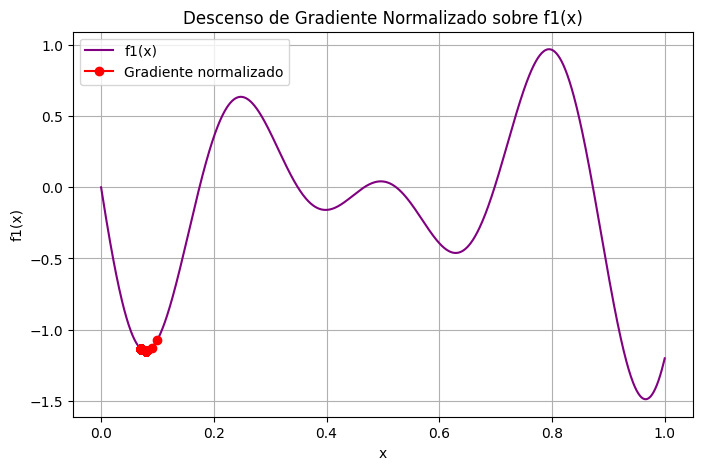

In [4]:

x = 0.1                  # Punto de inicio
alpha = 0.01             # Tasa de aprendizaje
tol = 1e-5               # Tolerancia de convergencia
max_iters = 1000         # Máximo número de iteraciones

# Historial de puntos
x_history = [x]

# Iteraciones del algoritmo
for _ in range(max_iters):
    grad = df1(x)
    norm = np.linalg.norm(grad)
    if norm < tol:
        break
    x_new = x - alpha * grad / norm
    if np.abs(x_new - x) < tol:
        break
    x = x_new
    x_history.append(x)

# Resultados
print(f"Mínimo aproximado: {x}")
print(f"Valor de la función en el mínimo: {f1(x)}")
print(f"Iteraciones realizadas: {len(x_history)}")

# Visualización
x_vals = np.linspace(0, 1, 1000)
y_vals = f1(x_vals)

plt.figure(figsize=(8,5))
plt.plot(x_vals, y_vals, label="f1(x)", color='purple')
plt.plot(x_history, [f1(xi) for xi in x_history], "ro-", label="Gradiente normalizado")
plt.title("Descenso de Gradiente Normalizado sobre f1(x)")
plt.xlabel("x")
plt.ylabel("f1(x)")
plt.legend()
plt.grid(True)
plt.show()


<p style="font-size:25px"> Función 2

Mínimo aproximado: 1.4999999999999996
Valor de la función en el mínimo: -0.25
Iteraciones realizadas: 6


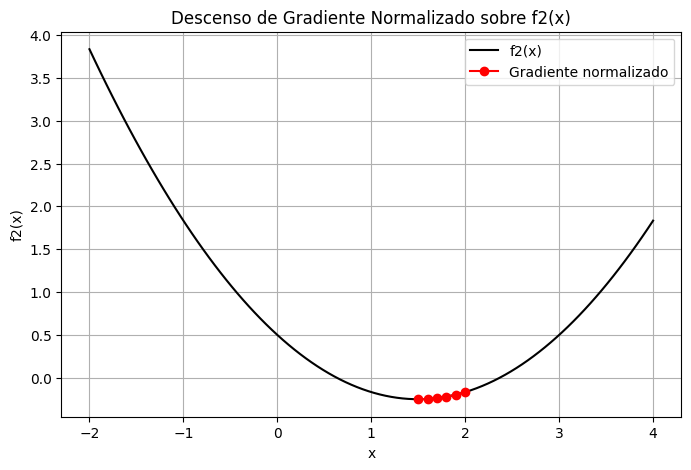

In [5]:

x = 2                    # Punto de inicio
alpha = 0.1              # Tasa de aprendizaje
tol = 1e-5               # Tolerancia
max_iters = 1000         # Número máximo de iteraciones

# Historial de valores
x_history = [x]

# Algoritmo iterativo
for _ in range(max_iters):
    grad = df2(x)
    norm = np.linalg.norm(grad)
    if norm < tol:
        break
    x_new = x - alpha * grad / norm
    if np.abs(x_new - x) < tol:
        break
    x = x_new
    x_history.append(x)

# Resultados
print(f"Mínimo aproximado: {x}")
print(f"Valor de la función en el mínimo: {f2(x)}")
print(f"Iteraciones realizadas: {len(x_history)}")

# Visualización
x_vals = np.linspace(-2, 4, 100)
y_vals = f2(x_vals)

plt.figure(figsize=(8,5))
plt.plot(x_vals, y_vals, label="f2(x)", color='black')
plt.plot(x_history, [f2(xi) for xi in x_history], "ro-", label="Gradiente normalizado")
plt.title("Descenso de Gradiente Normalizado sobre f2(x)")
plt.xlabel("x")
plt.ylabel("f2(x)")
plt.legend()
plt.grid(True)
plt.show()

# Método 2: Gradiente descendente con paso fijo

<p style="font-size:25px">Función 1

Mínimo aproximado: 0.07937552766612245
Valor de f1 en el mínimo: -1.1501730228055527
Iteraciones realizadas: 15


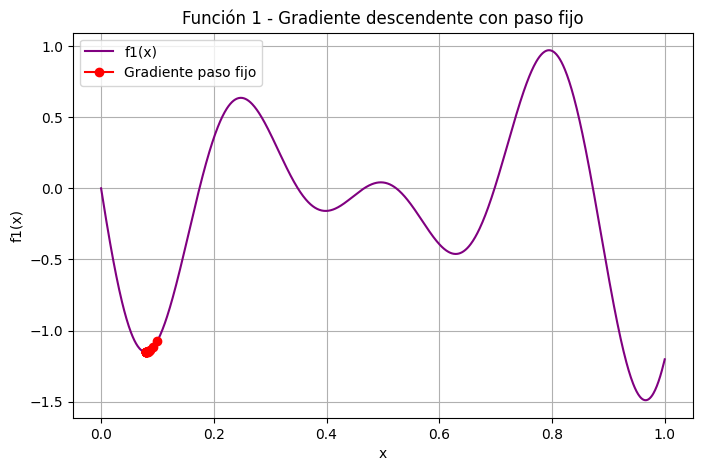

In [6]:

x = 0.1                  # Punto de partida
alpha = 0.001            # Paso fijo
tol = 1e-5               # Tolerancia de convergencia
max_iters = 1000         # Límite de iteraciones

# Historial de valores
x_history = [x]

# Descenso de gradiente con paso fijo
for _ in range(max_iters):
    grad = df1(x)
    x_new = x - alpha * grad
    if np.abs(x_new - x) < tol:
        break
    x = x_new
    x_history.append(x)

# Resultados
print(f"Mínimo aproximado: {x}")
print(f"Valor de f1 en el mínimo: {f1(x)}")
print(f"Iteraciones realizadas: {len(x_history)}")

# Visualización
x_vals = np.linspace(0, 1, 1000)

plt.figure(figsize=(8, 5))
plt.plot(x_vals, f1(x_vals), label="f1(x)", color="purple")
plt.plot(x_history, [f1(xi) for xi in x_history], "ro-", label="Gradiente paso fijo")
plt.title("Función 1 - Gradiente descendente con paso fijo")
plt.xlabel("x")
plt.ylabel("f1(x)")
plt.legend()
plt.grid(True)
plt.show()


<p style="font-size:25px">Función 2

Mínimo aproximado: 1.5001456497172263
Valor de f2 en el mínimo: -0.24999999292871988
Iteraciones realizadas: 119


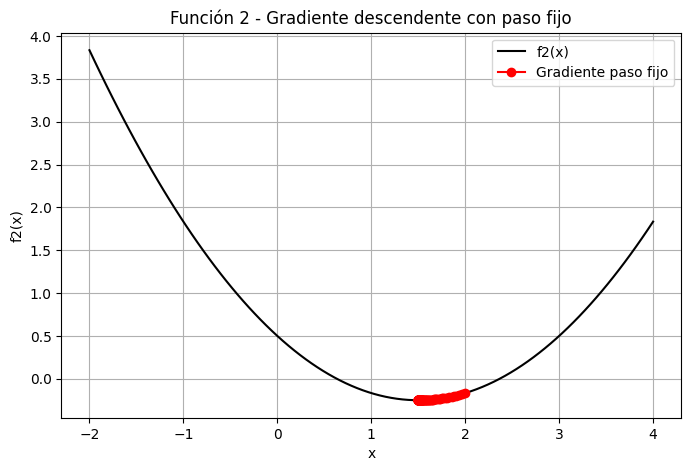

In [7]:

x = 2                   # Valor inicial
alpha = 0.1             # Paso fijo (learning rate)
tol = 1e-5              # Tolerancia para detener
max_iters = 1000        # Límite máximo de iteraciones

# Historial de iteraciones
x_history = [x]

# Descenso de gradiente con paso fijo
for _ in range(max_iters):
    grad = df2(x)
    x_new = x - alpha * grad
    if np.abs(x_new - x) < tol:
        break
    x = x_new
    x_history.append(x)

# Resultados
print(f"Mínimo aproximado: {x}")
print(f"Valor de f2 en el mínimo: {f2(x)}")
print(f"Iteraciones realizadas: {len(x_history)}")

# Visualización
x_vals = np.linspace(-2, 4, 100)
y_vals = f2(x_vals)

plt.figure(figsize=(8,5))
plt.plot(x_vals, y_vals, label="f2(x)", color="black")
plt.plot(x_history, [f2(xi) for xi in x_history], "ro-", label="Gradiente paso fijo")
plt.title("Función 2 - Gradiente descendente con paso fijo")
plt.xlabel("x")
plt.ylabel("f2(x)")
plt.legend()
plt.grid(True)
plt.show()


# Método 3: Newton-Raphson

<p style="font-size:25px"> Función 1

Mínimo aproximado: 0.07935168895740959
Valor de f1 en el mínimo: -1.1501731330421954
Iteraciones realizadas: 4


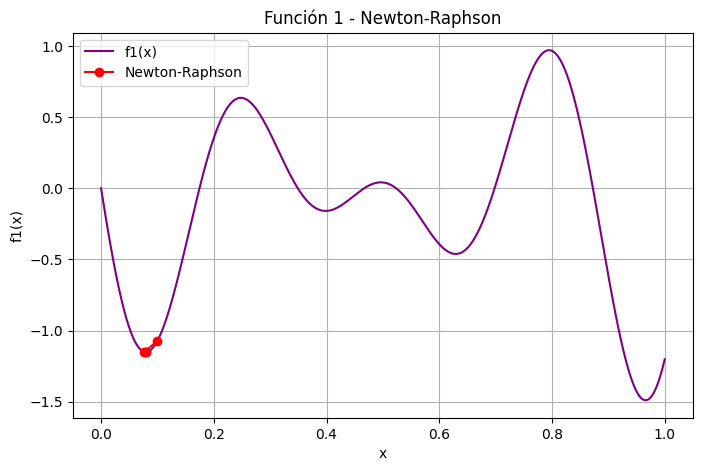

In [8]:
# Parámetros
x = 0.1
tol = 1e-5
max_iters = 1000

x_history = [x]
count = 0

# Método de Newton-Raphson
for _ in range(max_iters):
    grad = df1(x)
    hess = ddf1(x)
    
    if abs(hess) < 1e-8:
        print("Hessiano muy pequeño. Se detiene.")
        break
    
    x_new = x - grad / hess
    
    if abs(x_new - x) < tol:
        break
    
    x = x_new
    x_history.append(x)
    count += 1

# Resultados
print(f"Mínimo aproximado: {x}")
print(f"Valor de f1 en el mínimo: {f1(x)}")
print(f"Iteraciones realizadas: {count+1}")

# Gráfico
x_vals = np.linspace(0, 1, 1000)
y_vals = f1(x_vals)

plt.figure(figsize=(8,5))
plt.plot(x_vals, y_vals, label="f1(x)", color="purple")
plt.plot(x_history, [f1(xi) for xi in x_history], "ro-", label="Newton-Raphson")
plt.title("Función 1 - Newton-Raphson")
plt.xlabel("x")
plt.ylabel("f1(x)")
plt.legend()
plt.grid(True)
plt.show()


<p style="font-size:25px"> Función 2

Mínimo aproximado: 1.5
Valor de f2 en el mínimo: -0.25
Iteraciones realizadas: 2


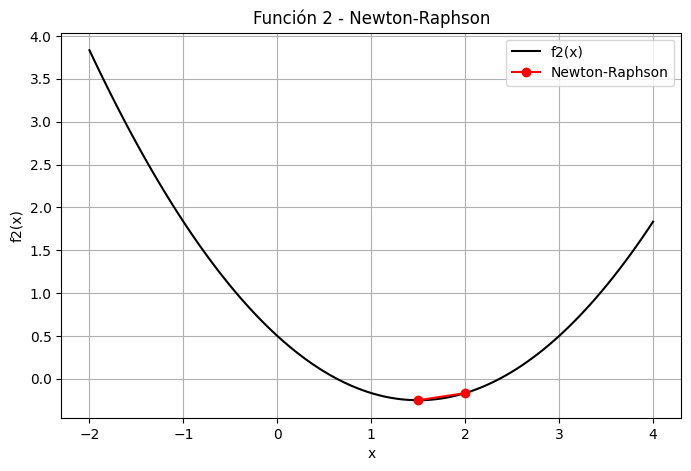

In [9]:
# Parámetros
x = 2
tol = 1e-5
max_iters = 1000

x_history = [x]
count = 0

# Método de Newton-Raphson
for _ in range(max_iters):
    grad = df2(x)
    hess = ddf2(x)
    
    if abs(hess) < 1e-8:
        print("Hessiano muy pequeño. Se detiene.")
        break
    
    x_new = x - grad / hess
    
    if abs(x_new - x) < tol:
        break
    
    x = x_new
    x_history.append(x)
    count += 1

# Resultados
print(f"Mínimo aproximado: {x}")
print(f"Valor de f2 en el mínimo: {f2(x)}")
print(f"Iteraciones realizadas: {count+1}")

# Gráfico
x_vals = np.linspace(-2, 4, 100)
y_vals = f2(x_vals)

plt.figure(figsize=(8,5))
plt.plot(x_vals, y_vals, label="f2(x)", color="black")
plt.plot(x_history, [f2(xi) for xi in x_history], "ro-", label="Newton-Raphson")
plt.title("Función 2 - Newton-Raphson")
plt.xlabel("x")
plt.ylabel("f2(x)")
plt.legend()
plt.grid(True)
plt.show()


## Tabla resumen de resultados

In [10]:
import pandas as pd

data = [
    ["Gradiente descendente con dirección normalizada - f1", 0.1, 1001, 0.080000, 0.08, 1.387779e-17],
    ["Gradiente descendente con paso fijo - f1", 0.1, 15, 0.079376, 0.08, 6.244723e-04],
    ["Newton-Raphson - f1", 0.1, 4, 0.079352, 0.08, 6.483110e-04],
    ["Gradiente descendente con dirección normalizada - f2", 2.0, 6, 1.500000, 1.50, 4.440892e-16],
    ["Gradiente descendente con paso fijo - f2", 2.0, 119, 1.500146, 1.50, 1.456497e-04],
    ["Newton-Raphson - f2", 2.0, 2, 1.500000, 1.50, 0.000000e+00],
]

df = pd.DataFrame(data, columns=["Método y Función", "Punto Inicial", "Total iteraciones", "Mínimo encontrado", "Mínimo real", "Distancia"])

df



,Método y Función,Punto Inicial,Total iteraciones,Mínimo encontrado,Mínimo real,Distancia
0,Gradiente descendente con dirección normalizad...,0.1,1001,0.080000,0.08,1.387779e-17
1,Gradiente descendente con paso fijo - f1,0.1,15,0.079376,0.08,6.244723e-04
2,Newton-Raphson - f1,0.1,4,0.079352,0.08,6.483110e-04
3,Gradiente descendente con dirección normalizad...,2.0,6,1.500000,1.50,4.440892e-16
4,Gradiente descendente con paso fijo - f2,2.0,119,1.500146,1.50,1.456497e-04
5,Newton-Raphson - f2,2.0,2,1.500000,1.50,0.000000e+00
